In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from matplotlib.ticker import FuncFormatter, MaxNLocator
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score

##### Fetch data

In [52]:
households_df = pd.read_csv("data/household.csv")
trips_df = pd.read_csv("data/trip.csv")
person_df = pd.read_csv("data/person.csv")

##### Build feature dataframe

In [53]:
df = pd.merge(person_df, trips_df, on = ["HOUSEHOLD_ID", "PERSON_ID"])
df = pd.merge(households_df, df, on = "HOUSEHOLD_ID")

df = df[["D_ACTIVITY", "TRAVELERS_TOTAL", "DISTANCE", "REPORTED_TRAVEL_TIME", "ARRIVAL_TIME_HHMM", "AGE", "GENDER", "EMPLOYMENT_STATUS", "J1_COMMUTE_FREQ", "J1_TELECOMMUTE_DAYS", "J1_BENEFITS_CARPOOL", "J1_BENEFITS_EV_CHARGING", "J1_BENEFITS_FREE_PARKING", "STUDENT_STATUS", "SCHOOL_FREQ", "VOLUNTEER_STATUS", "HOME_TYPE", "HOME_OWNERSHIP", "HHSIZE", "NUMSTUDENTS", "NUMDRIVERS", "NUMWORKERS", "NUMVEHICLE", "HH_INCOME_DETAILED", "HHTRIPS"]]

arrival = pd.to_datetime(df["ARRIVAL_TIME_HHMM"], format = "%H:%M")
df["ARRIVAL_TIME_HHMM"] = arrival.dt.hour * 60 + arrival.dt.minute

print(f"Number of trips: {len(df)}")
df

Number of trips: 126874


,D_ACTIVITY,TRAVELERS_TOTAL,DISTANCE,REPORTED_TRAVEL_TIME,ARRIVAL_TIME_HHMM,AGE,GENDER,EMPLOYMENT_STATUS,J1_COMMUTE_FREQ,J1_TELECOMMUTE_DAYS,...,VOLUNTEER_STATUS,HOME_TYPE,HOME_OWNERSHIP,HHSIZE,NUMSTUDENTS,NUMDRIVERS,NUMWORKERS,NUMVEHICLE,HH_INCOME_DETAILED,HHTRIPS
0,2,1,5.098000,10,565,59,1,0,-9,0,...,-9,1,1,3,1,3,3,4,8,7
1,5,1,1.443000,4,690,59,1,0,-9,0,...,-9,1,1,3,1,3,3,4,8,7
2,5,1,0.627000,8,748,59,1,0,-9,0,...,-9,1,1,3,1,3,3,4,8,7
3,2,1,0.856000,8,760,59,1,0,-9,0,...,-9,1,1,3,1,3,3,4,8,7
4,1,1,5.097000,21,1035,59,1,0,-9,0,...,-9,1,1,3,1,3,3,4,8,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126869,7,3,17.296973,35,1130,60,1,2,-9,-9,...,1,1,1,2,0,2,1,3,7,5
126870,1,2,17.296973,35,1235,60,1,2,-9,-9,...,1,1,1,2,0,2,1,3,7,5
126871,2,1,20.940748,45,435,64,2,0,1,-9,...,1,1,1,2,0,2,1,3,7,5
126872,5,1,15.713282,35,995,64,2,0,1,-9,...,1,1,1,2,0,2,1,3,7,5


##### Remove outliers with iso forest

In [54]:
iso_forest = IsolationForest(contamination = 0.05, random_state = 42)
outlier_mask = iso_forest.fit_predict(df) == -1
print(f"Outliers removed: {outlier_mask.sum()}")
df = df[~outlier_mask].reset_index(drop = True)

Outliers removed: 6344


##### Visualize data with 2d umap

/Users/aryuh/Documents/ev_digital_city/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


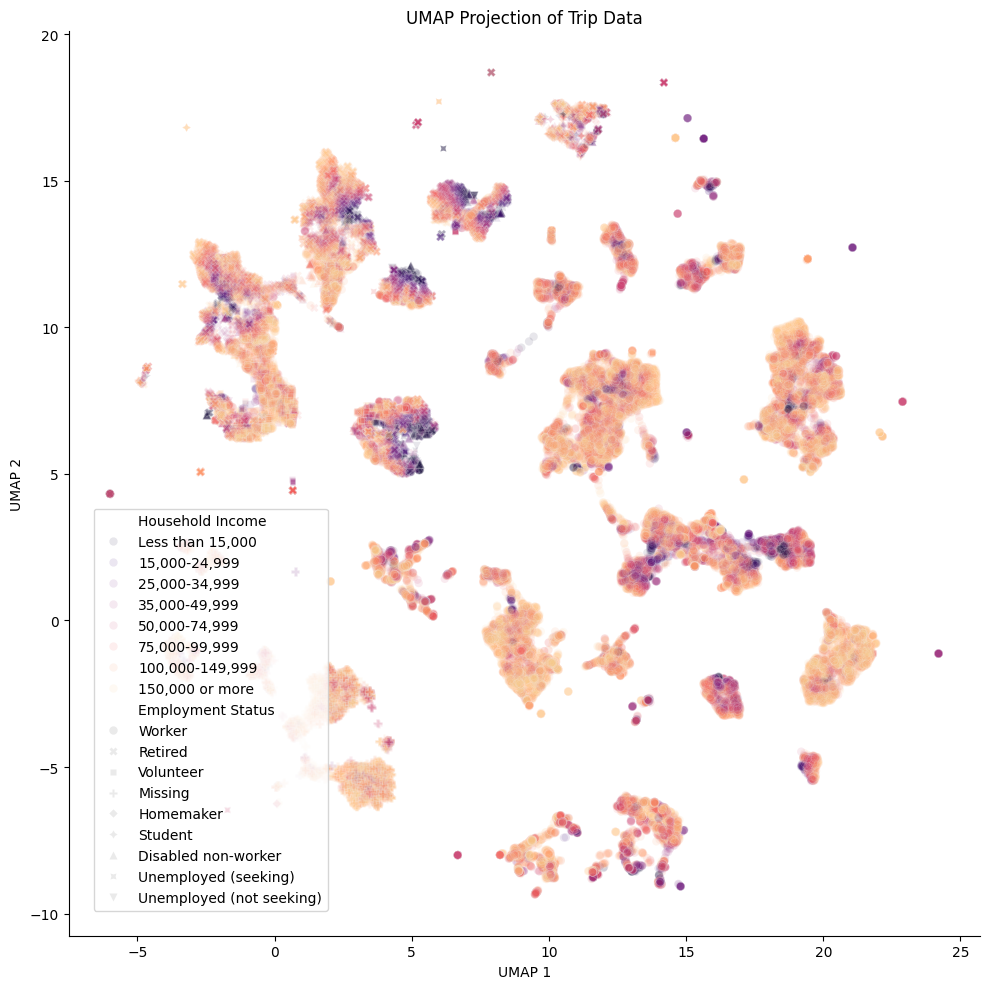

In [55]:
scaled_df = StandardScaler().fit_transform(df)
embedding = umap.UMAP(n_components = 2, random_state = 42).fit_transform(scaled_df)

umap_df = pd.DataFrame(embedding, columns = ["UMAP1", "UMAP2"])
employment_labels = {
    -9: "Missing",
    0: "Worker",
    1: "Retired",
    2: "Volunteer",
    3: "Homemaker",
    4: "Unemployed (seeking)",
    5: "Unemployed (not seeking)",
    6: "Student",
    7: "Disabled non-worker",
}
umap_df["Employment Status"] = df["EMPLOYMENT_STATUS"].map(employment_labels)
income_labels = {
    1: "Less than 15,000",
    2: "15,000-24,999",
    3: "25,000-34,999",
    4: "35,000-49,999",
    5: "50,000-74,999",
    6: "75,000-99,999",
    7: "100,000-149,999",
    8: "150,000 or more",
}
umap_df["Household Income"] = df["HH_INCOME_DETAILED"].map(income_labels)
income_order = [income_labels[code] for code in sorted(income_labels)]

plt.figure(figsize = (10, 10))
ax = sns.scatterplot(data = umap_df, x = "UMAP1", y = "UMAP2", hue = "Household Income", hue_order = income_order, style = "Employment Status", palette = "magma", alpha = 0.1)
plt.title("UMAP Projection of Trip Data")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
ax.legend(loc = "lower left", bbox_to_anchor = (0.02, 0.02), frameon = True)
sns.despine()
plt.tight_layout()
plt.show()

##### Correlation martix and skewness

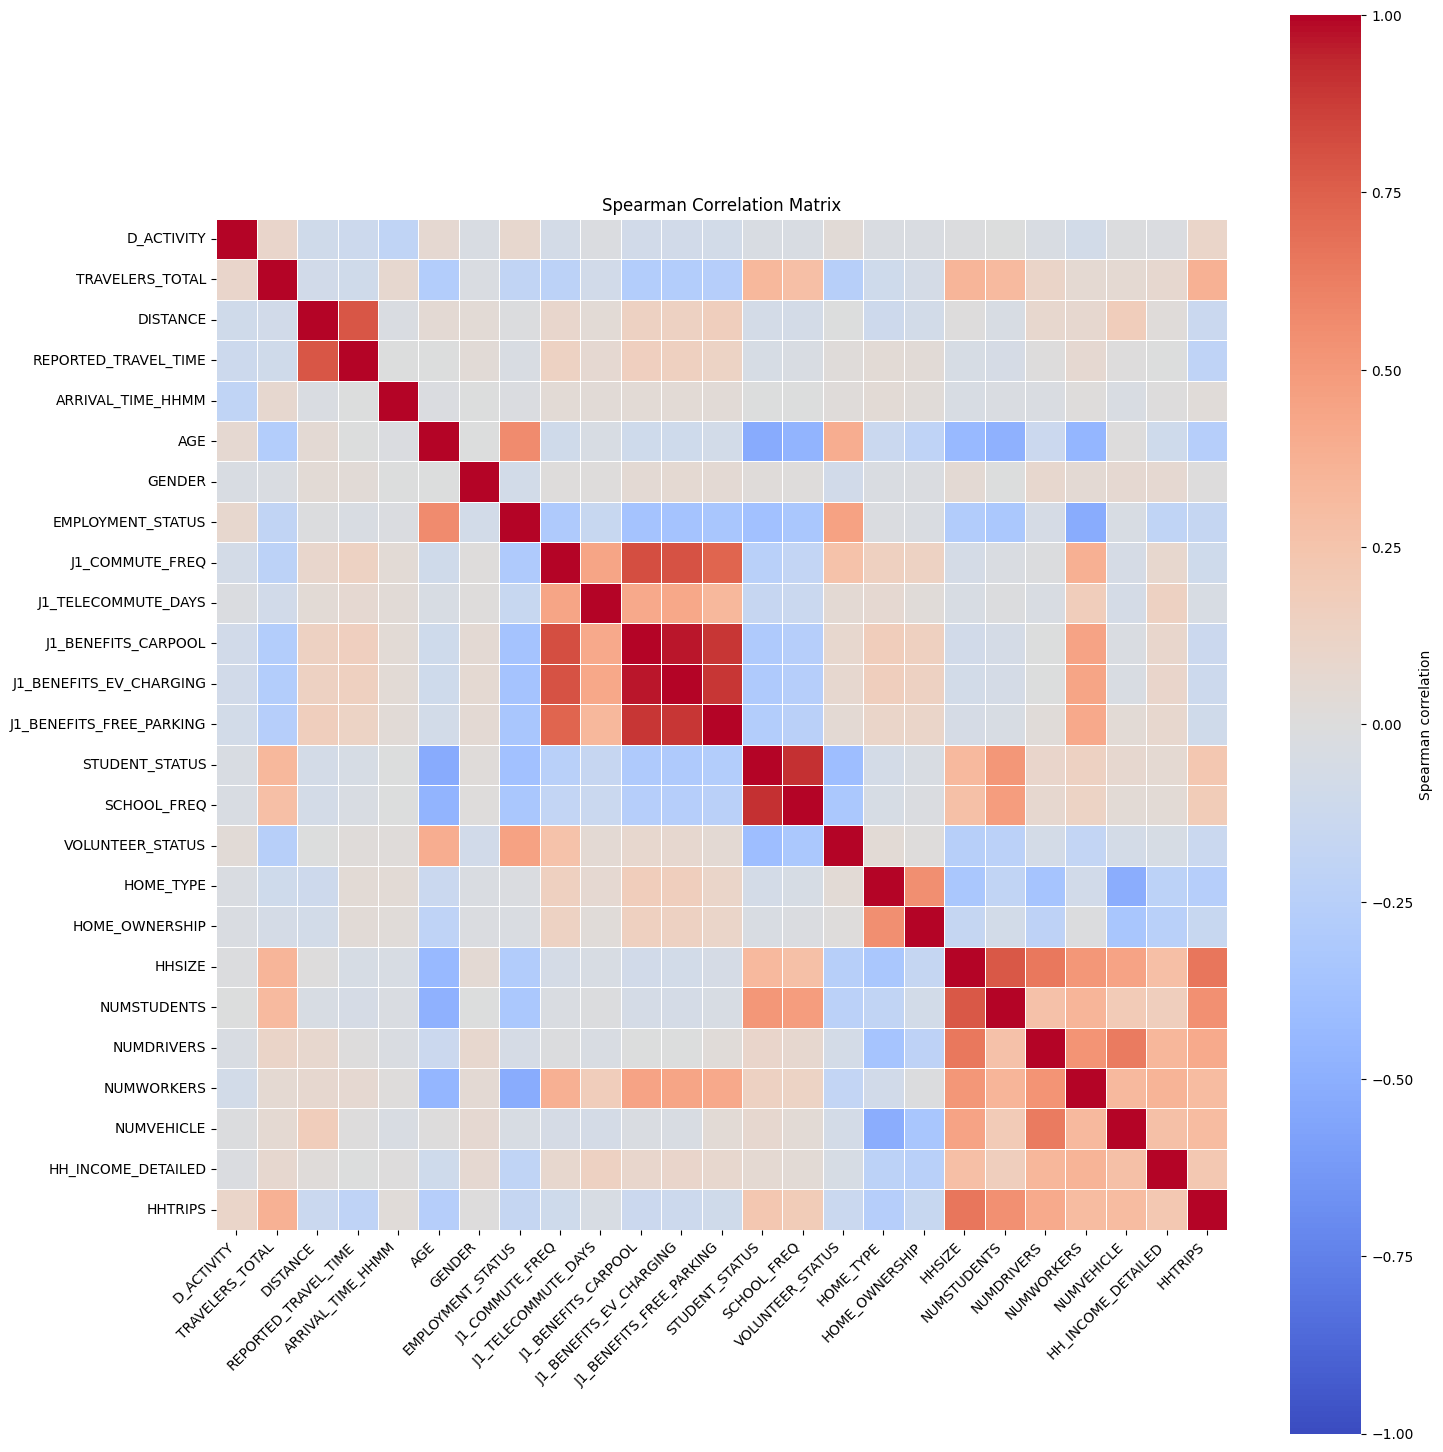

DISTANCE                    66.424427
REPORTED_TRAVEL_TIME         8.651191
TRAVELERS_TOTAL              7.593154
SCHOOL_FREQ                  2.317395
J1_TELECOMMUTE_DAYS          1.595054
NUMSTUDENTS                  1.250032
HHTRIPS                      1.240773
D_ACTIVITY                   1.158393
NUMVEHICLE                   0.817298
STUDENT_STATUS               0.774571
HHSIZE                       0.708898
NUMDRIVERS                   0.657260
HOME_TYPE                    0.476995
NUMWORKERS                   0.106487
J1_COMMUTE_FREQ              0.029708
ARRIVAL_TIME_HHMM           -0.143661
AGE                         -0.275812
J1_BENEFITS_FREE_PARKING    -0.342817
J1_BENEFITS_EV_CHARGING     -0.356634
J1_BENEFITS_CARPOOL         -0.359274
GENDER                      -0.796421
HH_INCOME_DETAILED          -1.307221
HOME_OWNERSHIP              -1.367261
EMPLOYMENT_STATUS           -1.656095
VOLUNTEER_STATUS            -1.773857
dtype: float64

In [56]:
corr_matrix = df.corr(method = "spearman")
skewness = df.skew().sort_values(ascending = False)

plt.figure(figsize = (15, 15))
sns.heatmap(
    corr_matrix,
    cmap = "coolwarm",
    center = 0,
    vmin = -1,
    vmax = 1,
    square = True,
    linewidths = 0.5,
    cbar_kws = {"label": "Spearman correlation"},
)
plt.title("Spearman Correlation Matrix")
plt.xticks(rotation = 45, ha = "right")
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

skewness

##### Cluster data with k-means

Selected k = 3 (silhouette = 0.237)


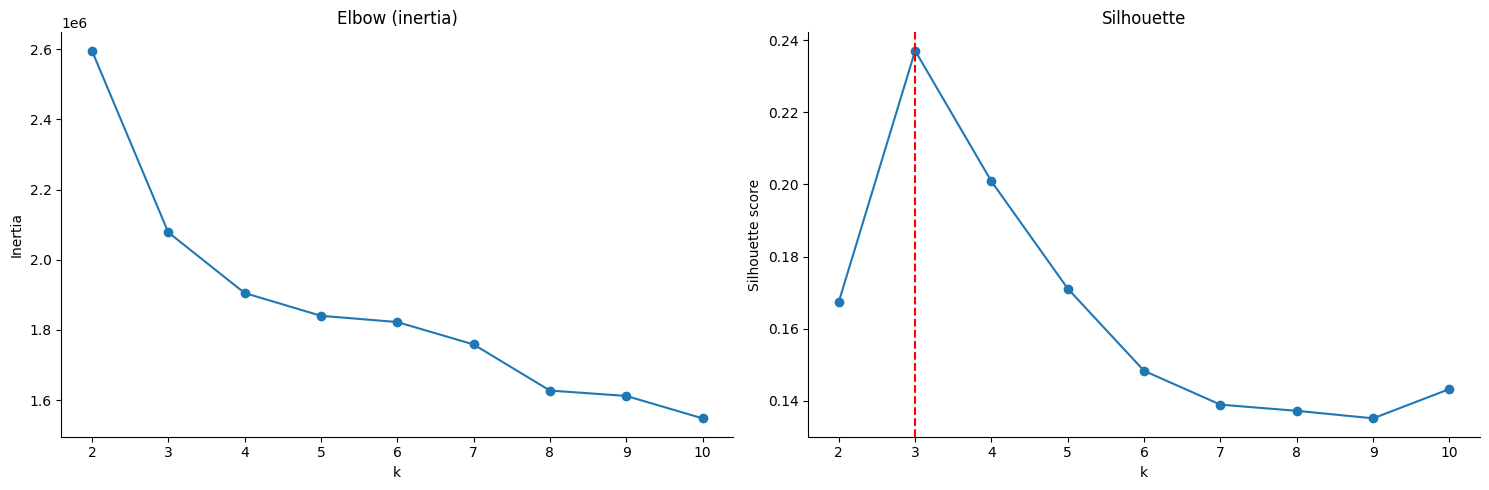

In [57]:
# Score each k: inertia (elbow) + silhouette (auto-pick)
k_range = range(2, 11)
inertias = []
silhouettes = []
for k in k_range:
    km = MiniBatchKMeans(n_clusters = k, random_state = 42, batch_size = 8000, n_init = 3).fit(scaled_df)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(scaled_df, km.labels_, sample_size = 10000, random_state = 42))

# Auto-pick k = highest silhouette
best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Selected k = {best_k} (silhouette = {max(silhouettes):.3f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))
ax1.plot(list(k_range), inertias, marker = "o")
ax1.set_title("Elbow (inertia)")
ax1.set_xlabel("k")
ax1.set_ylabel("Inertia")
ax2.plot(list(k_range), silhouettes, marker = "o")
ax2.axvline(best_k, color = "red", linestyle = "--")
ax2.set_title("Silhouette")
ax2.set_xlabel("k")
ax2.set_ylabel("Silhouette score")
sns.despine()
plt.tight_layout()
plt.show()

# Final fit on auto-selected k
kmeans = KMeans(n_clusters = best_k, random_state = 42, n_init = 10)
clusters = kmeans.fit_predict(scaled_df)
umap_df["Cluster"] = clusters.astype(str)

##### Visualize clusters

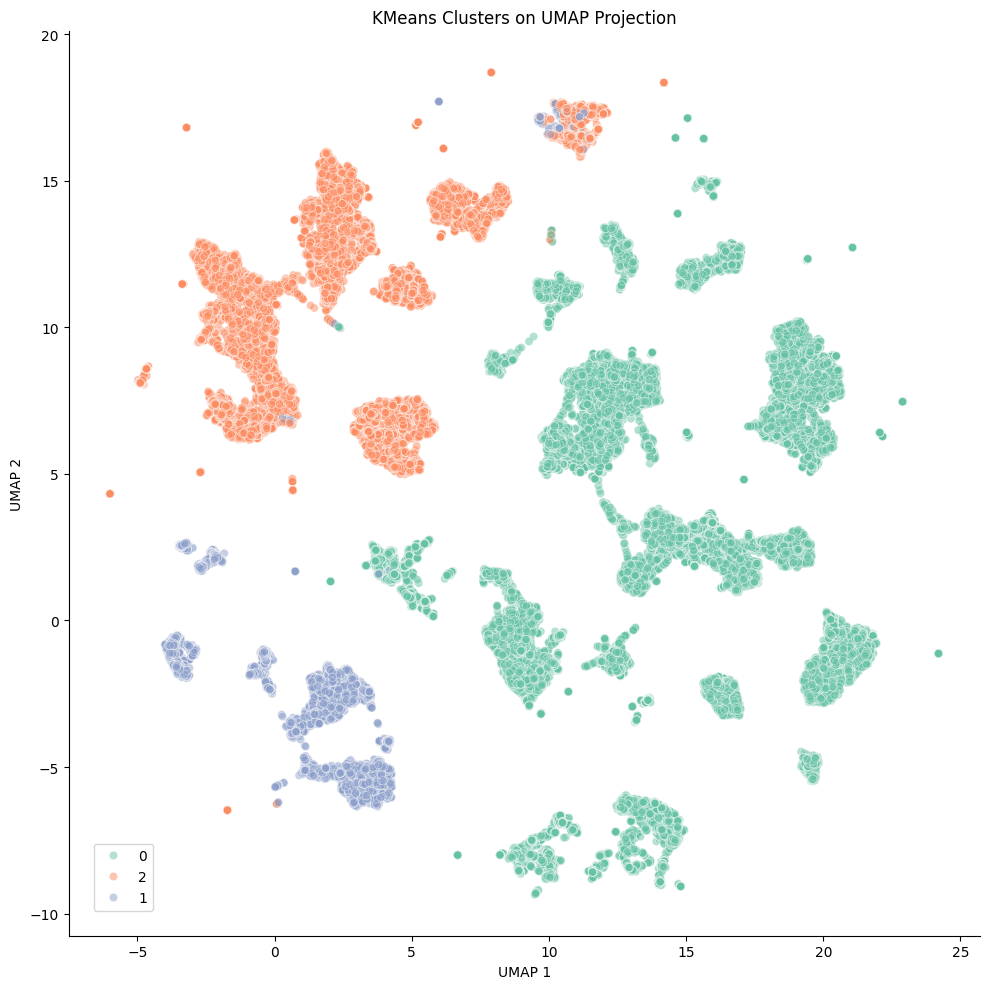

In [58]:
plt.figure(figsize = (10, 10))
ax = sns.scatterplot(data = umap_df, x = "UMAP1", y = "UMAP2", hue = "Cluster", palette = "Set2", alpha = 0.5)
plt.title("KMeans Clusters on UMAP Projection")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
ax.legend(loc = "lower left", bbox_to_anchor = (0.02, 0.02), frameon = True)
sns.despine()
plt.tight_layout()
plt.show()

##### Group data by cluster

In [59]:
cluster_dfs = [df[clusters == c] for c in range(best_k)]
for c, cluster_df in enumerate(cluster_dfs):
    print(f"Cluster {c}: {len(cluster_df)} rows")

Cluster 0: 70961 rows
Cluster 1: 13303 rows
Cluster 2: 36266 rows


##### Graphs for each cluster

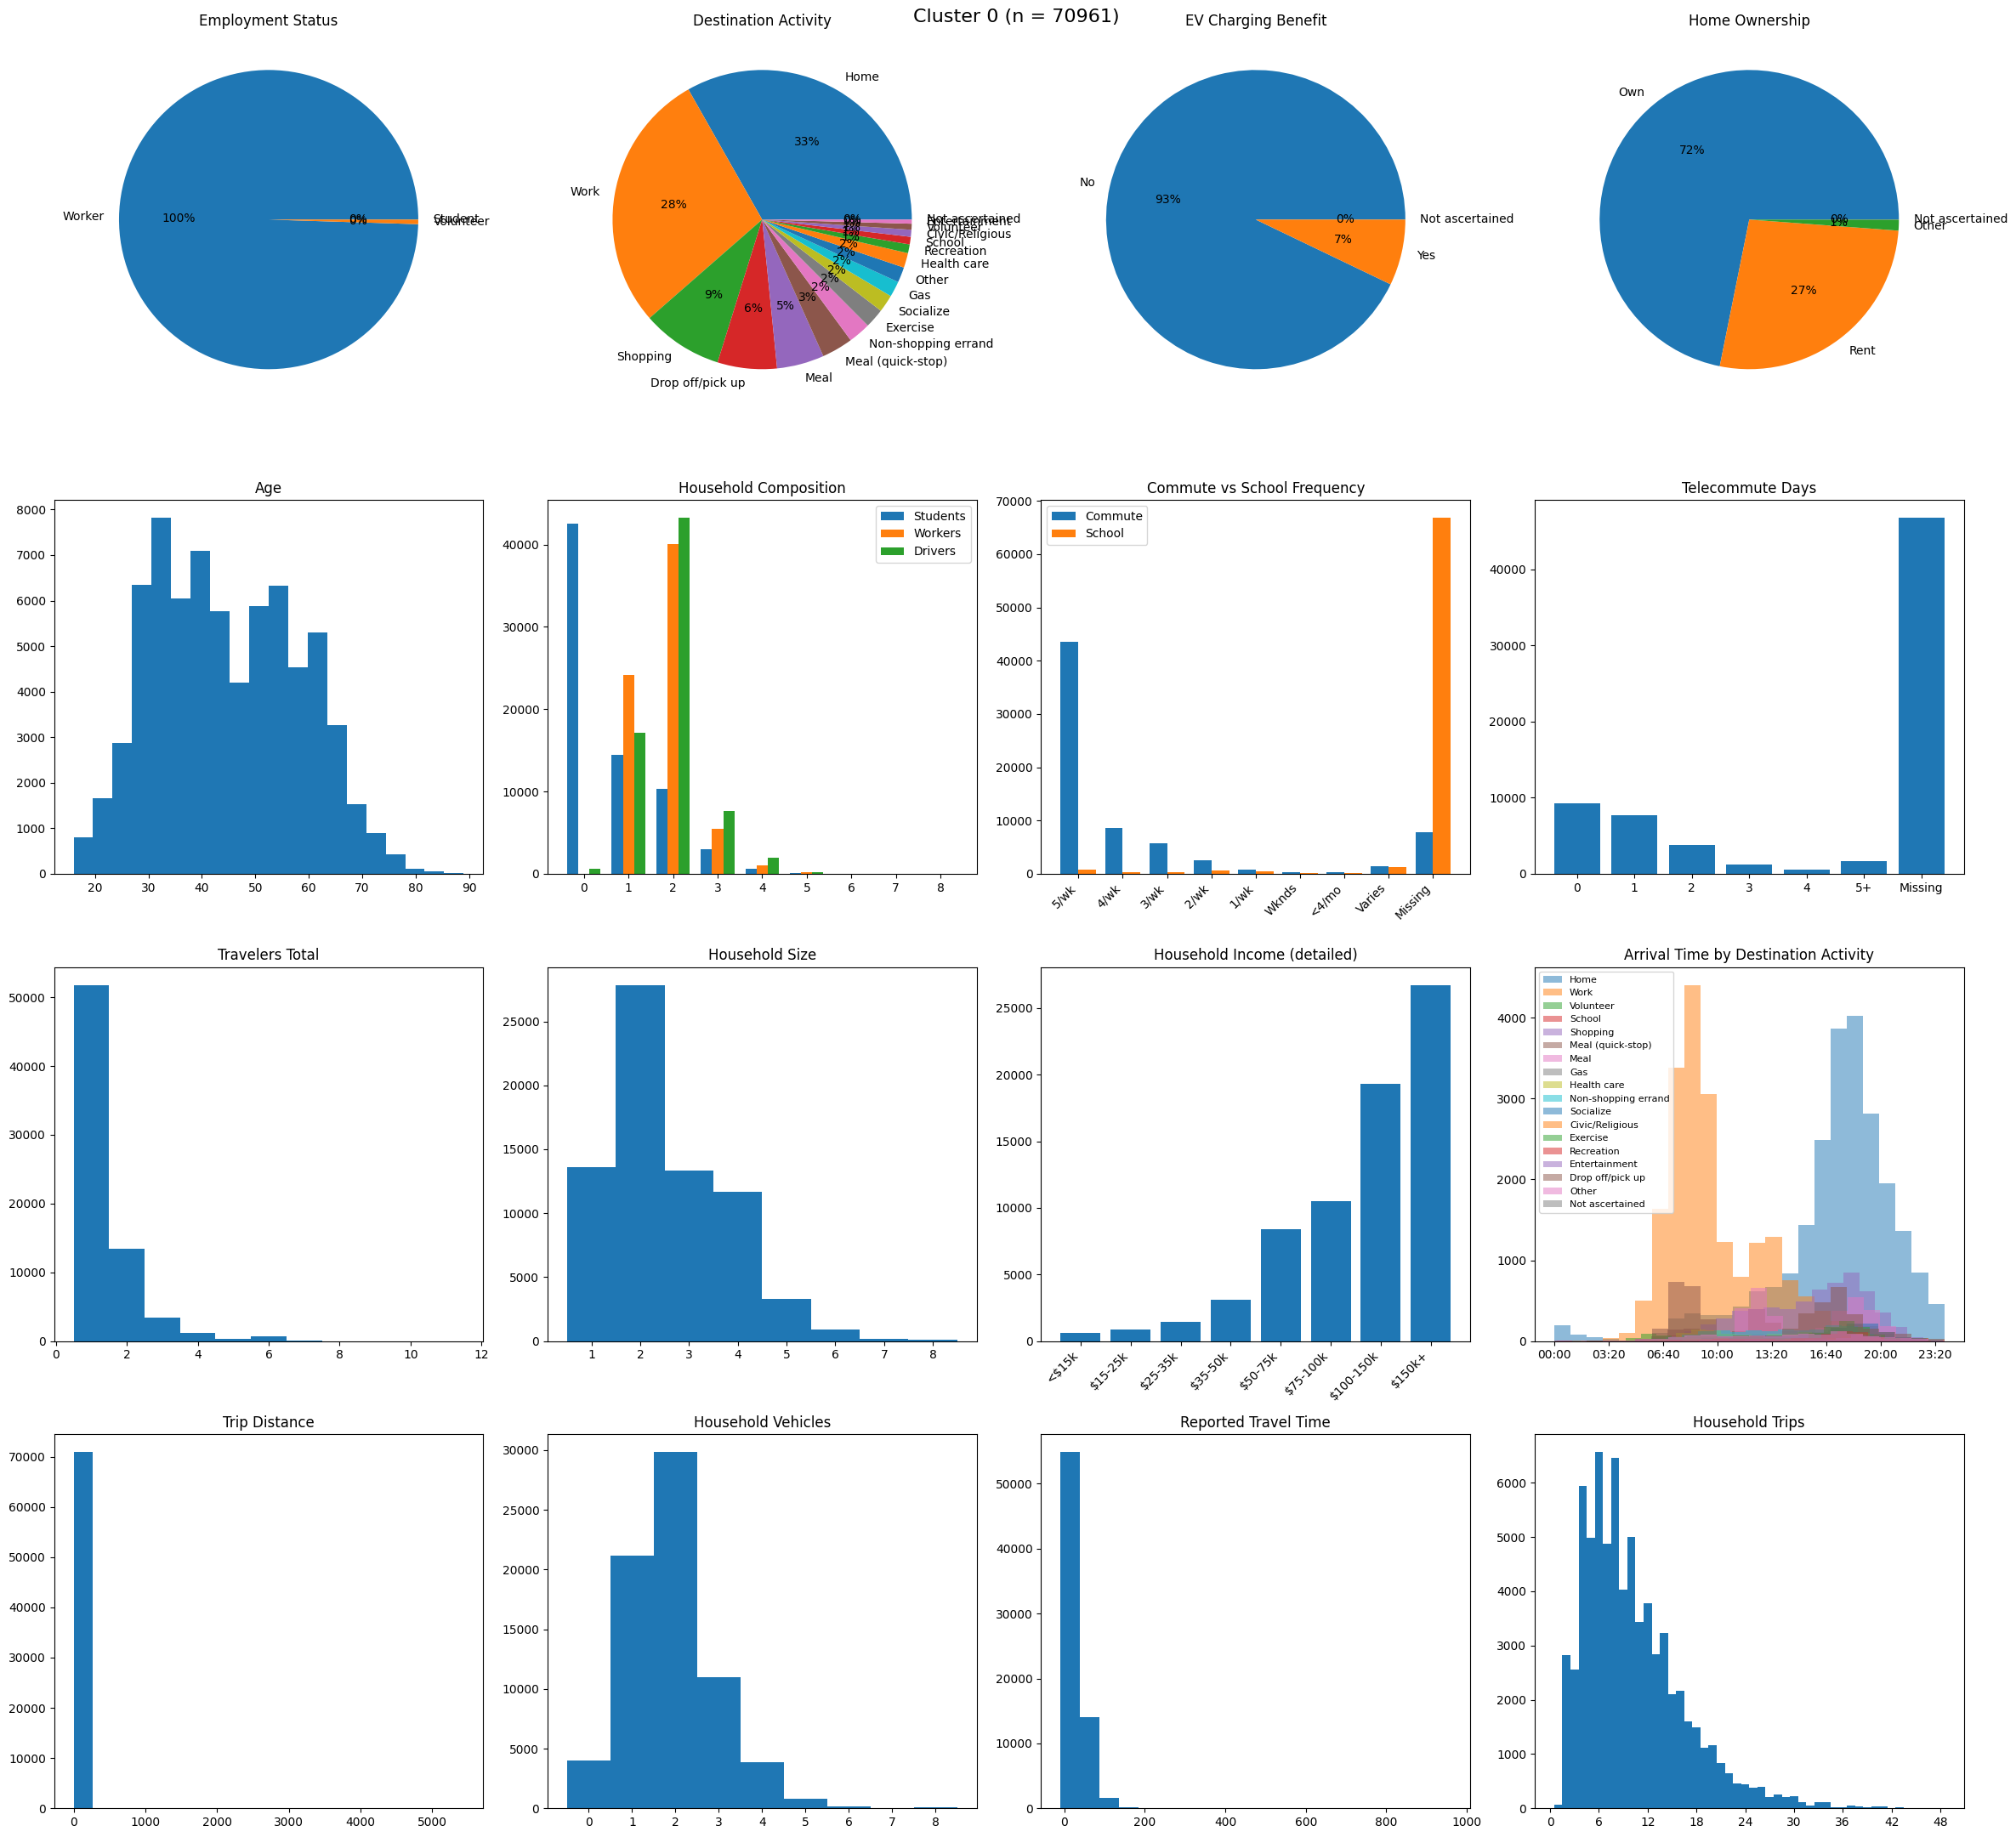

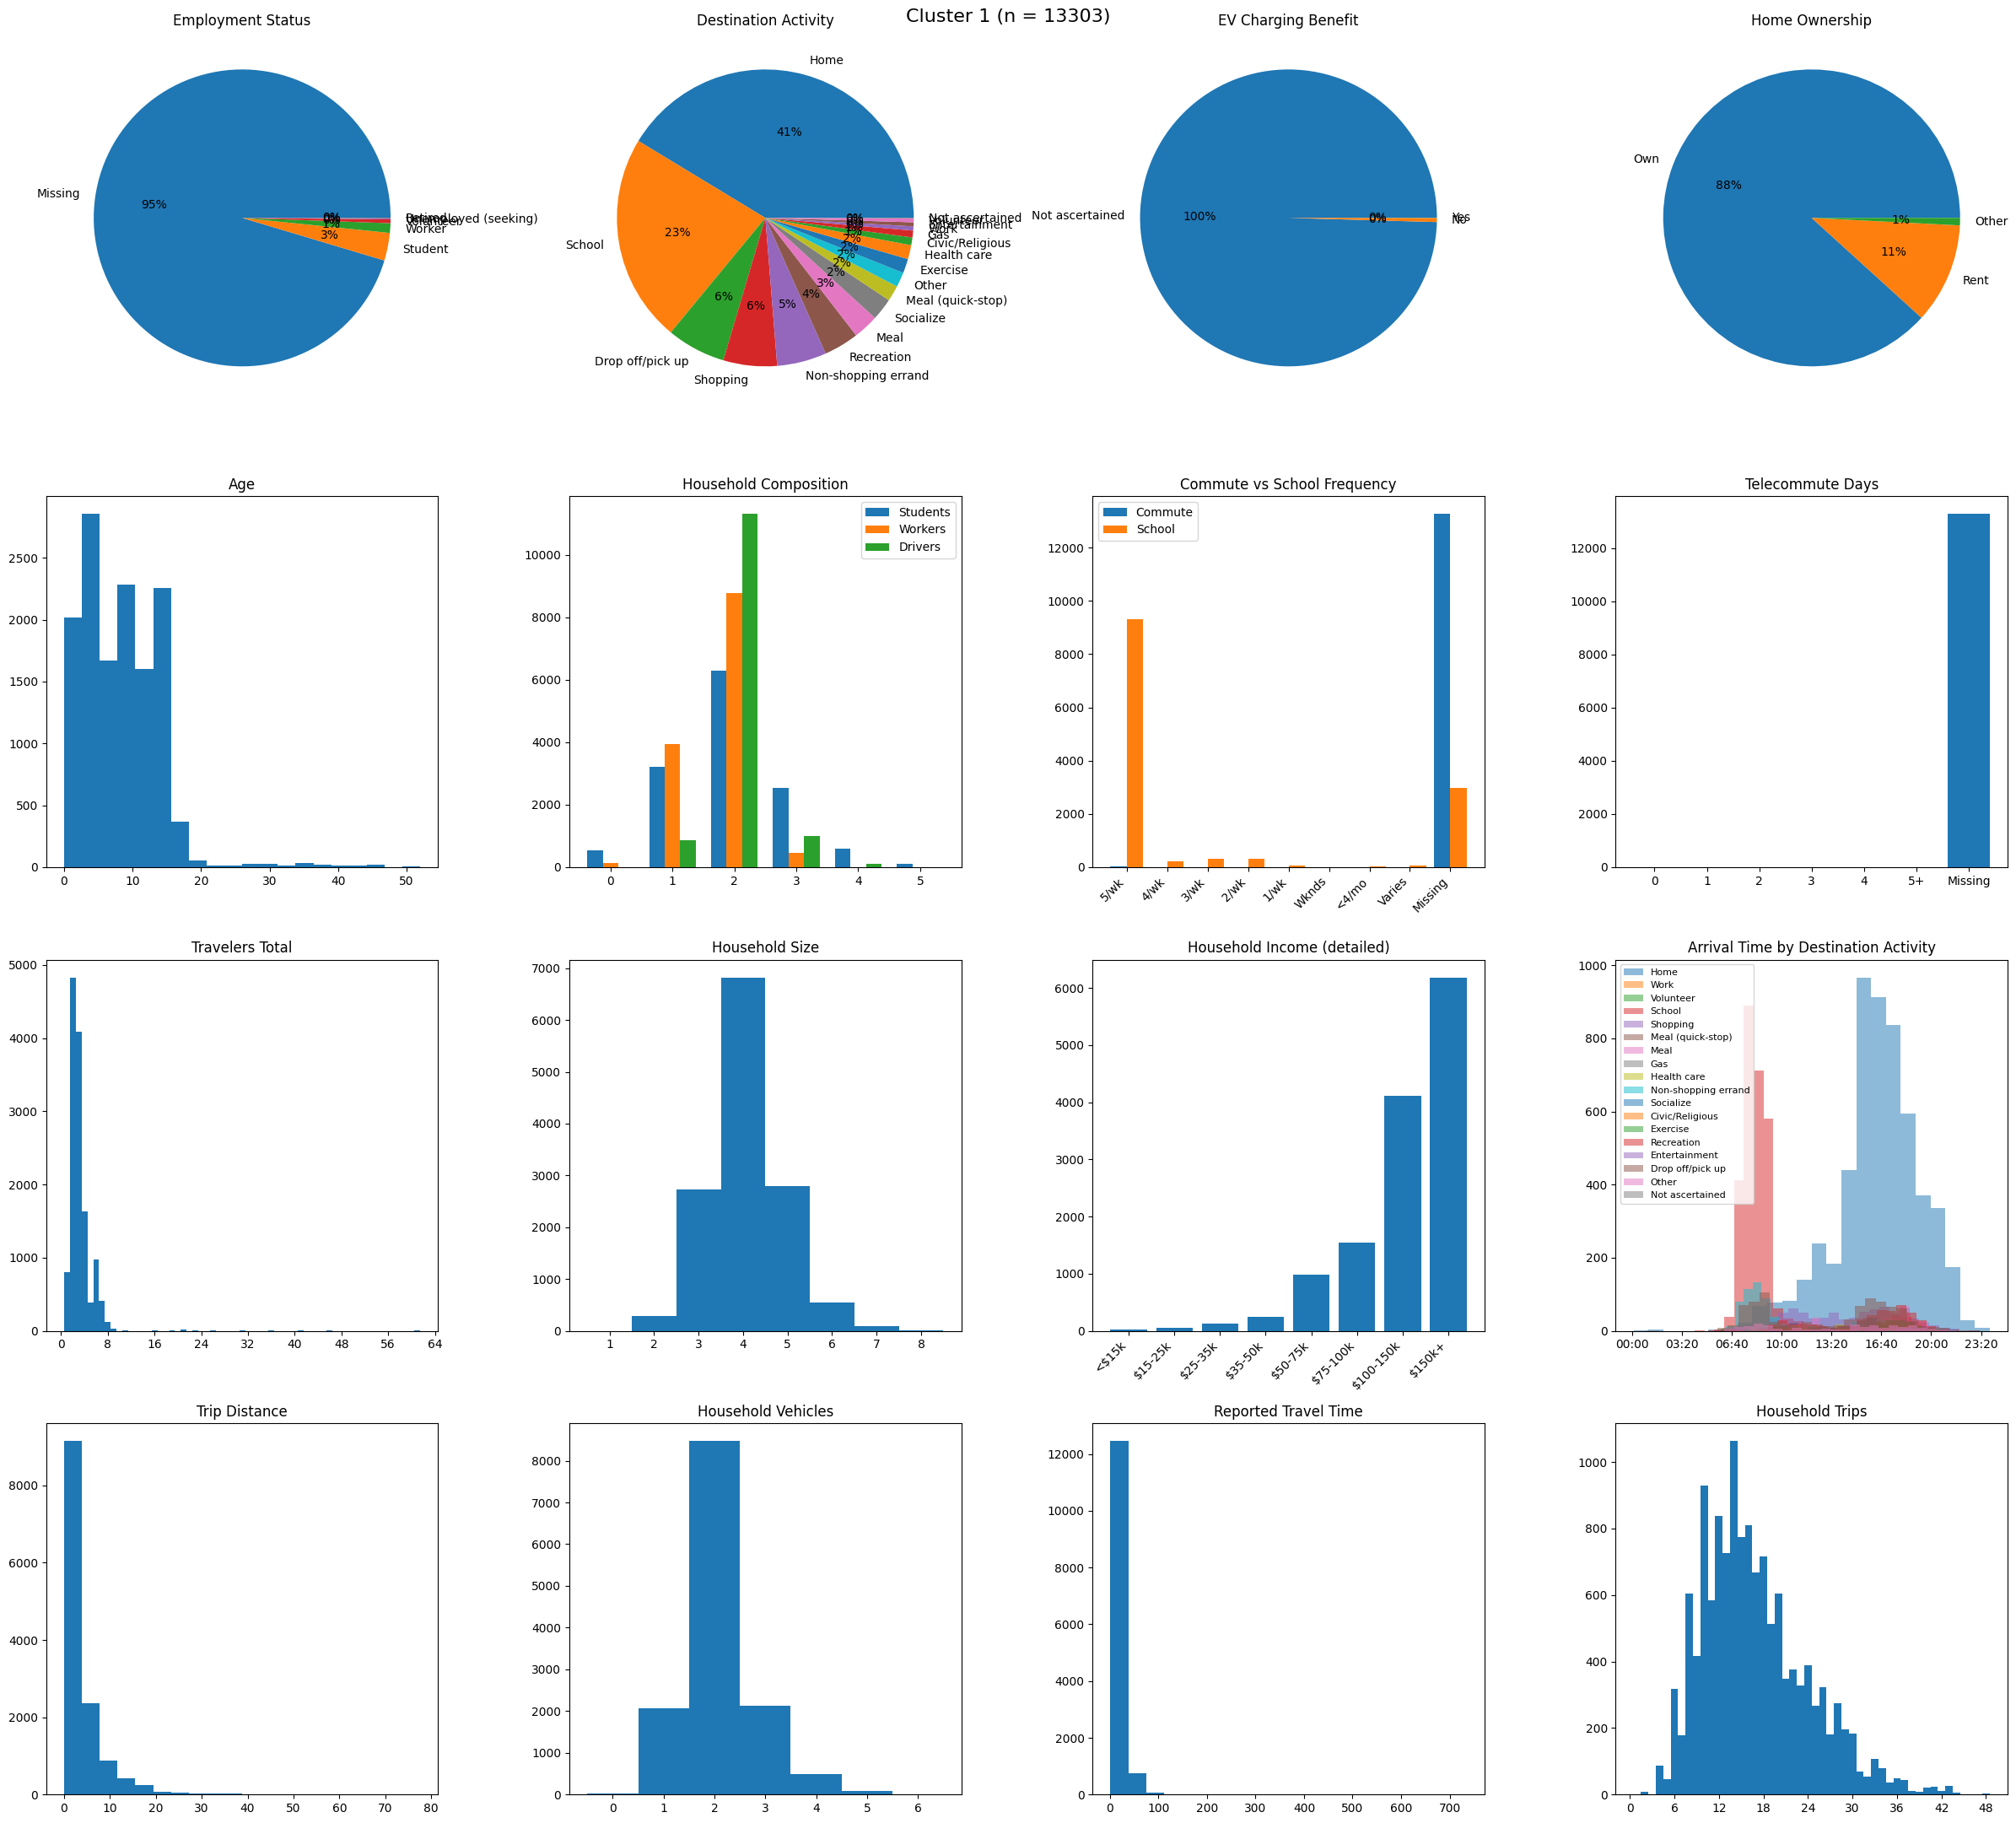

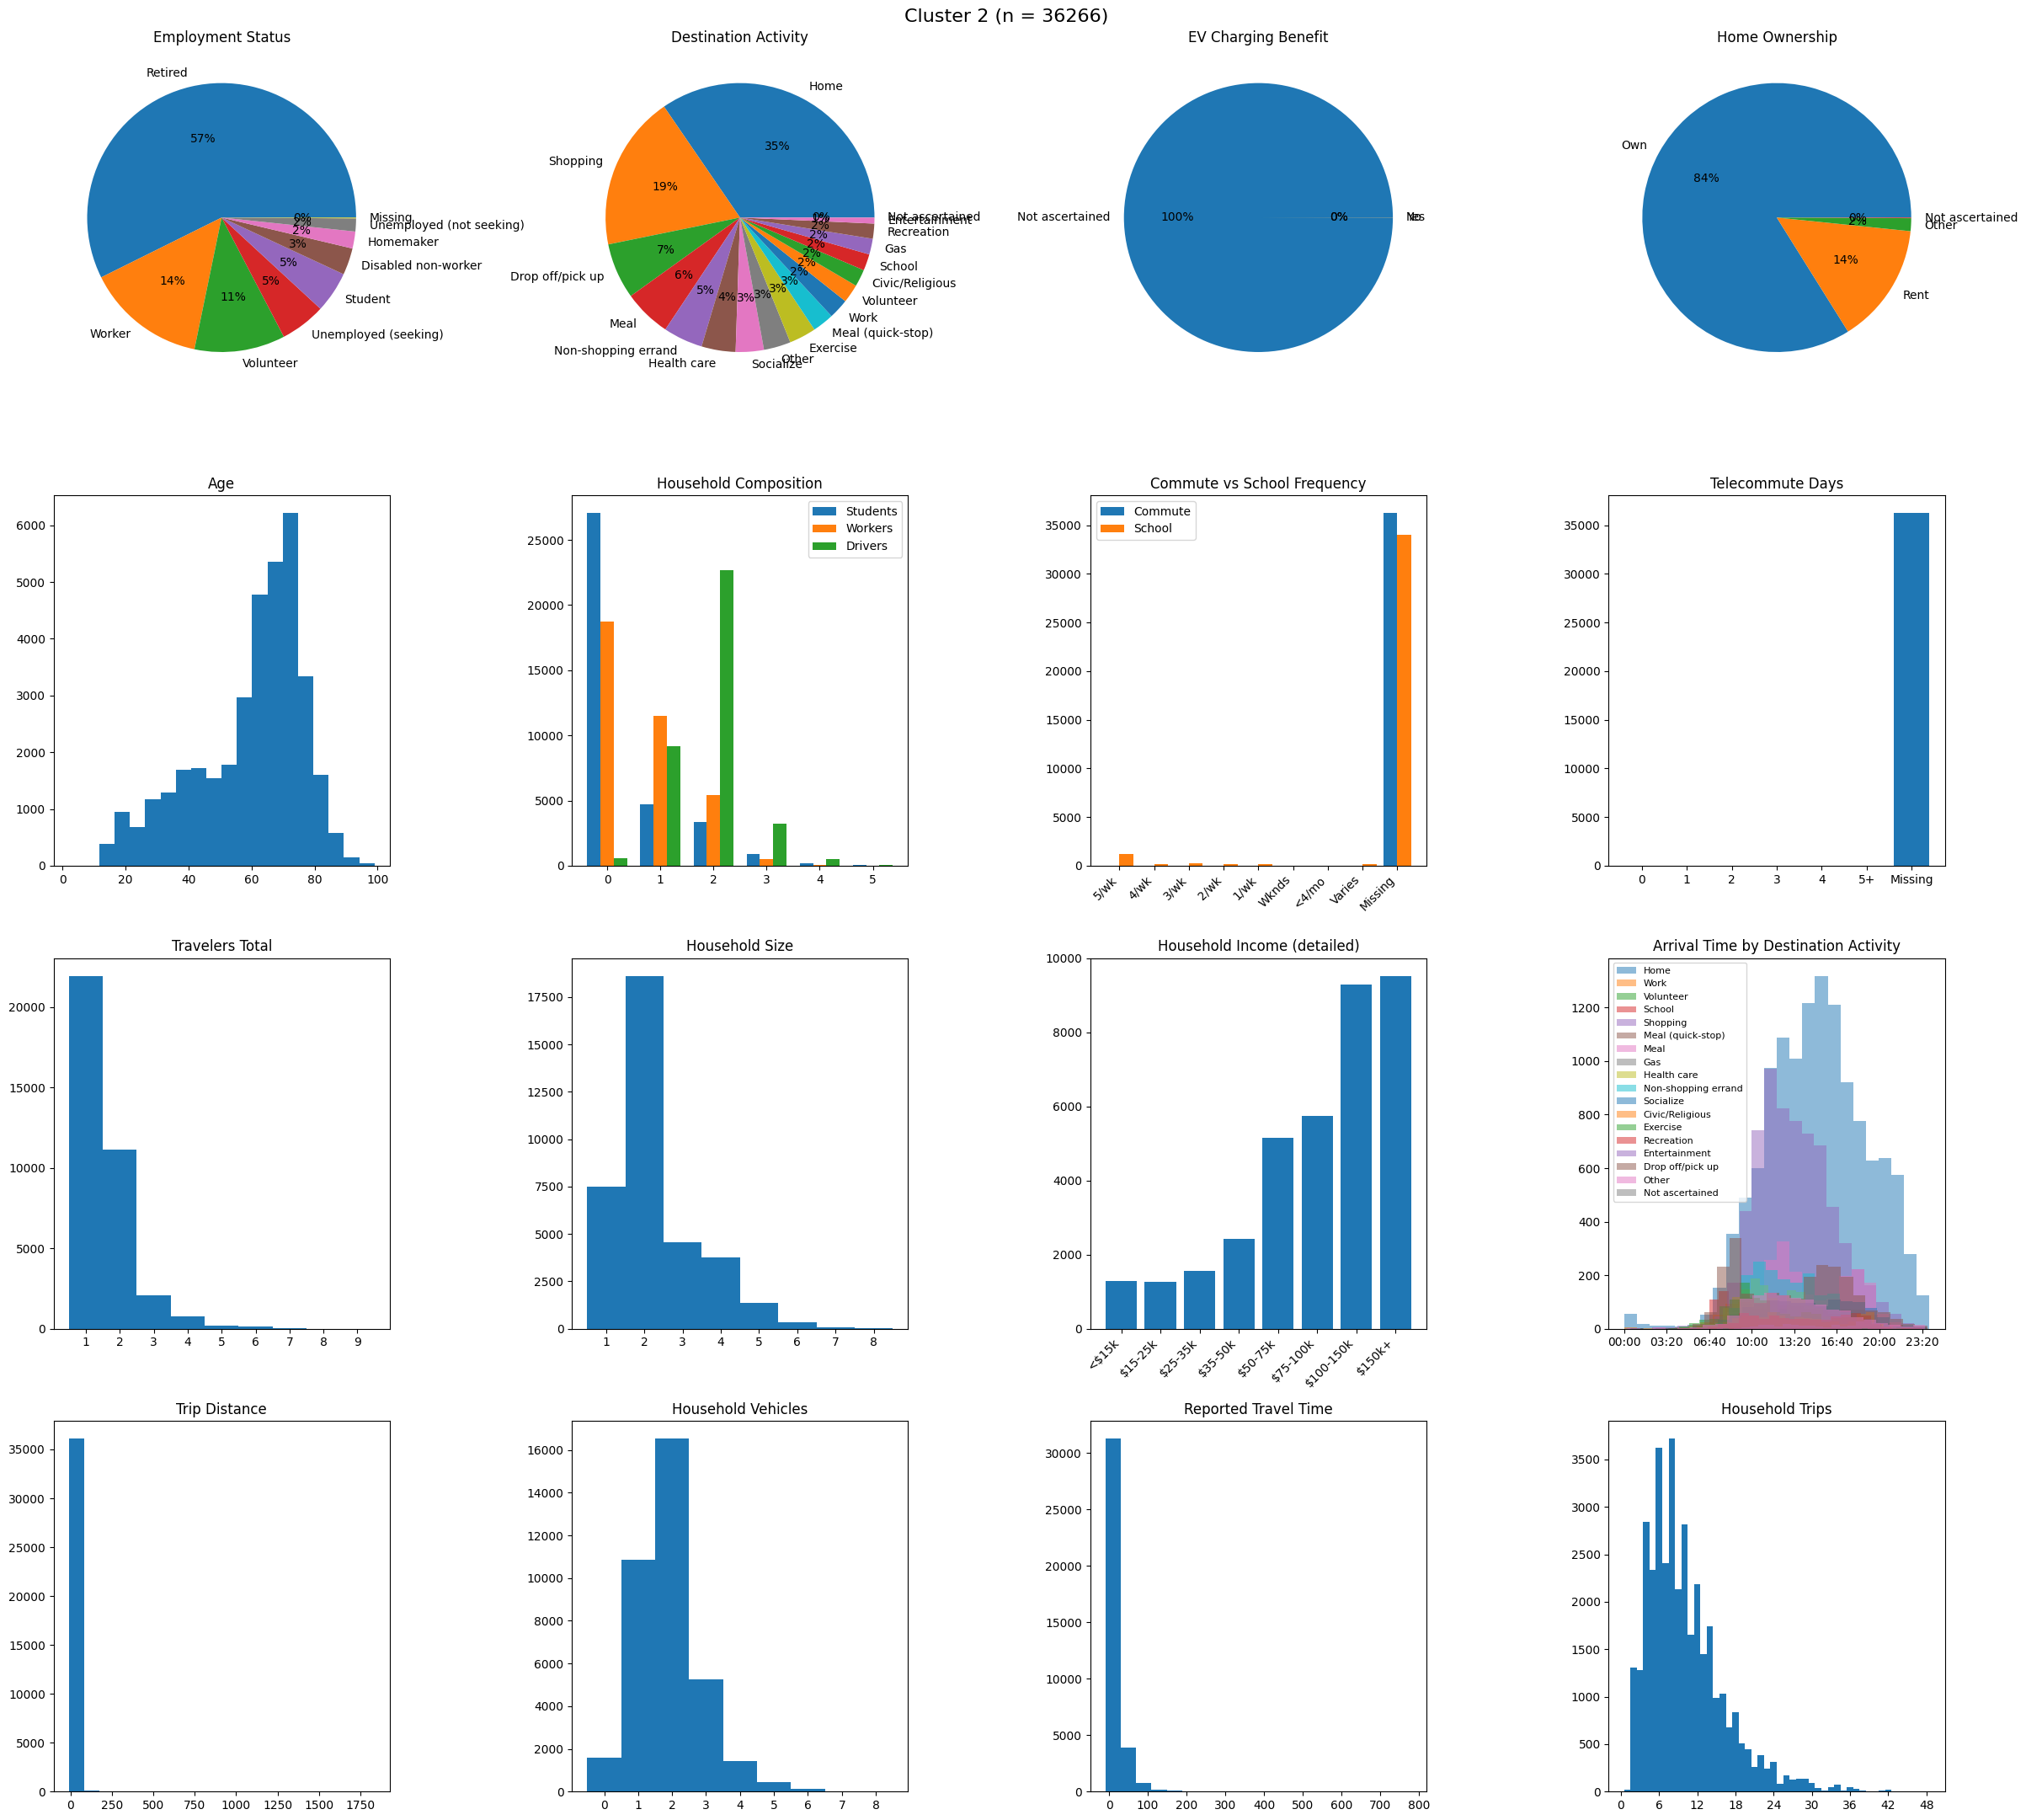

In [60]:
activity_labels = {
    1: "Home", 2: "Work", 3: "Volunteer", 4: "School", 5: "Shopping",
    6: "Meal (quick-stop)", 7: "Meal", 8: "Gas", 9: "Health care",
    10: "Non-shopping errand", 11: "Socialize", 12: "Civic/Religious",
    13: "Exercise", 14: "Recreation", 15: "Entertainment",
    16: "Drop off/pick up", 18: "Other", -9: "Not ascertained",
}
ev_charging_labels = {0: "No", 1: "Yes", -9: "Not ascertained"}
ownership_labels = {1: "Own", 2: "Rent", 3: "Other", -9: "Not ascertained"}
student_status_labels = {0: "Not a student", 1: "Student", -9: "Not ascertained"}
freq_order = [1, 2, 3, 4, 5, 6, 7, 8, -9]
freq_tick = {1: "5/wk", 2: "4/wk", 3: "3/wk", 4: "2/wk", 5: "1/wk", 6: "Wknds", 7: "<4/mo", 8: "Varies", -9: "Missing"}
tele_order = [0, 1, 2, 3, 4, 5, -9]
tele_tick = {0: "0", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5+", -9: "Missing"}
income_amounts = {
    1: "<$15k", 2: "$15-25k", 3: "$25-35k", 4: "$35-50k",
    5: "$50-75k", 6: "$75-100k", 7: "$100-150k", 8: "$150k+",
}


def graph_cluster(cluster_df: pd.DataFrame, title_prefix: str) -> None:
    fig, axes = plt.subplots(4, 4, figsize = (24, 22))
    fig.suptitle(f"{title_prefix} (n = {len(cluster_df)})", fontsize = 16)

    def pie(ax, series, labels, title):
        counts = series.map(labels).value_counts()
        ax.pie(counts, labels = counts.index, autopct = "%1.0f%%")
        ax.set_title(title)

    def int_hist(ax, series, title):
        bins = np.arange(series.min(), series.max() + 2) - 0.5
        ax.hist(series, bins = bins)
        ax.xaxis.set_major_locator(MaxNLocator(integer = True))
        ax.set_title(title)

    if (cluster_df["EMPLOYMENT_STATUS"] == -9).all():
        pie(axes[0, 0], cluster_df["STUDENT_STATUS"], student_status_labels, "Student Status")
    else:
        pie(axes[0, 0], cluster_df["EMPLOYMENT_STATUS"], employment_labels, "Employment Status")
    pie(axes[0, 1], cluster_df["D_ACTIVITY"], activity_labels, "Destination Activity")
    pie(axes[0, 2], cluster_df["J1_BENEFITS_EV_CHARGING"], ev_charging_labels, "EV Charging Benefit")
    pie(axes[0, 3], cluster_df["HOME_OWNERSHIP"], ownership_labels, "Home Ownership")

    axes[1, 0].hist(cluster_df["AGE"], bins = 20)
    axes[1, 0].set_title("Age")

    comp_order = list(range(0, int(max(cluster_df["NUMSTUDENTS"].max(), cluster_df["NUMWORKERS"].max(), cluster_df["NUMDRIVERS"].max())) + 1))
    student_counts = cluster_df["NUMSTUDENTS"].value_counts().reindex(comp_order, fill_value = 0)
    worker_counts = cluster_df["NUMWORKERS"].value_counts().reindex(comp_order, fill_value = 0)
    driver_counts = cluster_df["NUMDRIVERS"].value_counts().reindex(comp_order, fill_value = 0)
    x = np.arange(len(comp_order))
    axes[1, 1].bar(x - 0.25, student_counts, width = 0.25, label = "Students")
    axes[1, 1].bar(x, worker_counts, width = 0.25, label = "Workers")
    axes[1, 1].bar(x + 0.25, driver_counts, width = 0.25, label = "Drivers")
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(comp_order)
    axes[1, 1].set_title("Household Composition")
    axes[1, 1].legend()

    commute_counts = cluster_df["J1_COMMUTE_FREQ"].value_counts().reindex(freq_order, fill_value = 0)
    school_counts = cluster_df["SCHOOL_FREQ"].value_counts().reindex(freq_order, fill_value = 0)
    x = np.arange(len(freq_order))
    axes[1, 2].bar(x - 0.2, commute_counts, width = 0.4, label = "Commute")
    axes[1, 2].bar(x + 0.2, school_counts, width = 0.4, label = "School")
    axes[1, 2].set_xticks(x)
    axes[1, 2].set_xticklabels([freq_tick[c] for c in freq_order], rotation = 45, ha = "right")
    axes[1, 2].set_title("Commute vs School Frequency")
    axes[1, 2].legend()

    tele_counts = cluster_df["J1_TELECOMMUTE_DAYS"].value_counts().reindex(tele_order, fill_value = 0)
    axes[1, 3].bar(np.arange(len(tele_order)), tele_counts)
    axes[1, 3].set_xticks(np.arange(len(tele_order)))
    axes[1, 3].set_xticklabels([tele_tick[c] for c in tele_order])
    axes[1, 3].set_title("Telecommute Days")

    int_hist(axes[2, 0], cluster_df["TRAVELERS_TOTAL"], "Travelers Total")
    int_hist(axes[2, 1], cluster_df["HHSIZE"], "Household Size")

    income_codes = sorted(income_amounts)
    income_counts = cluster_df["HH_INCOME_DETAILED"].value_counts().reindex(income_codes, fill_value = 0)
    axes[2, 2].bar(np.arange(len(income_codes)), income_counts)
    axes[2, 2].set_xticks(np.arange(len(income_codes)))
    axes[2, 2].set_xticklabels([income_amounts[c] for c in income_codes], rotation = 45, ha = "right")
    axes[2, 2].set_title("Household Income (detailed)")

    # Arrival time by destination activity, overlaid, skip empty activities; HH:MM x labels
    ax = axes[2, 3]
    for code, label in activity_labels.items():
        sub = cluster_df.loc[cluster_df["D_ACTIVITY"] == code, "ARRIVAL_TIME_HHMM"]
        if len(sub) == 0:
            continue
        ax.hist(sub, bins = 24, alpha = 0.5, label = label)
    ax.set_title("Arrival Time by Destination Activity")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda m, _: f"{int(m) // 60:02d}:{int(m) % 60:02d}"))
    ax.legend(fontsize = 8)

    axes[3, 0].hist(cluster_df["DISTANCE"], bins = 20)
    axes[3, 0].set_title("Trip Distance")
    int_hist(axes[3, 1], cluster_df["NUMVEHICLE"], "Household Vehicles")
    axes[3, 2].hist(cluster_df["REPORTED_TRAVEL_TIME"], bins = 20)
    axes[3, 2].set_title("Reported Travel Time")
    int_hist(axes[3, 3], cluster_df["HHTRIPS"], "Household Trips")

    plt.tight_layout()
    plt.show()


for cluster_id, cluster_df in enumerate(cluster_dfs):
    graph_cluster(cluster_df, f"Cluster {cluster_id}")